In [54]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [55]:
BASE = "../raw_csv"   # since notebook is in Week08/notebooks
print("BASE exists:", Path(BASE).exists())



BASE exists: True


In [56]:
import os
from pathlib import Path
import pandas as pd

BASE = "../raw_csv"

all_curves = []

for sub in sorted(os.listdir(BASE)):
    folder = Path(BASE) / sub
    if not folder.is_dir():
        continue

    for f in os.listdir(folder):
        # only Ag scan files
        if "ag" not in f.lower():
            continue
        if "scan" not in f.lower():
            continue

        path = folder / f
        print("Loading:", path)

        try:
            df = pd.read_csv(path)
        except Exception as e:
            print("Failed to read:", f, e)
            continue

        # normalize column names
        df.columns = [c.lower().strip() for c in df.columns]

        # normalize current column name
        rename_map = {
            "current density": "current",
            "j": "current"
        }
        df = df.rename(columns=rename_map)

        if "voltage" not in df.columns or "current" not in df.columns:
            print("Skipping (missing columns):", f, df.columns.tolist())
            continue

        df["voltage"] = pd.to_numeric(df["voltage"], errors="coerce")
        df["current"] = pd.to_numeric(df["current"], errors="coerce")
        df = df.dropna(subset=["voltage", "current"])

        # infer HTL from filename (before first underscore)
        htl = f.split("_")[0]

        df["HTL"] = htl
        df["Electrode"] = "Ag"
        df["SourceFile"] = f   # IMPORTANT for grouping later

        all_curves.append(df)

# combine all into one DataFrame
if all_curves:
    curves = pd.concat(all_curves, ignore_index=True)
else:
    curves = pd.DataFrame()

print("Total rows loaded:", len(curves))
curves.head()

Loading: ..\raw_csv\type2_breakdown_Ag\MeO2PACz_Ag_scan_10V.csv
Loading: ..\raw_csv\type2_breakdown_Ag\NiOx_Ag_scan_10V.csv
Loading: ..\raw_csv\type2_breakdown_Ag\PEDOT_Ag_scan_10V.csv
Loading: ..\raw_csv\type2_breakdown_Ag\polyTPD_Ag_scan_10V.csv
Loading: ..\raw_csv\type2_breakdown_Ag\PTAA_Ag_scan_10V.csv
Total rows loaded: 2305


,voltage,current,HTL,Electrode,SourceFile
0,1.50,-414.630968,MeO2PACz,Ag,MeO2PACz_Ag_scan_10V.csv
1,1.48,-385.656368,MeO2PACz,Ag,MeO2PACz_Ag_scan_10V.csv
2,1.46,-356.903254,MeO2PACz,Ag,MeO2PACz_Ag_scan_10V.csv
3,1.44,-328.702929,MeO2PACz,Ag,MeO2PACz_Ag_scan_10V.csv
4,1.42,-301.120664,MeO2PACz,Ag,MeO2PACz_Ag_scan_10V.csv


In [57]:
curves["HTL"].value_counts()

HTL
NiOx        601
PTAA        601
polyTPD     601
PEDOT       351
MeO2PACz    151
Name: count, dtype: int64

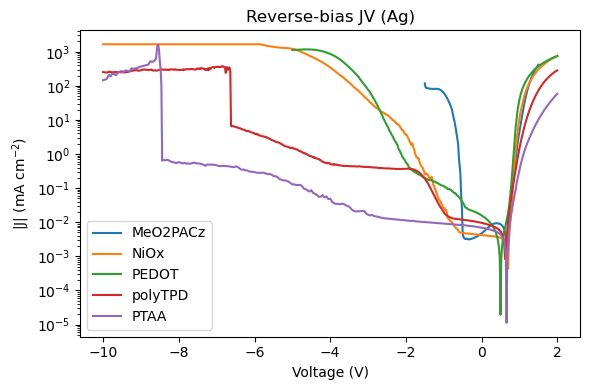

In [58]:
plt.figure(figsize=(6,4))

for htl in curves["HTL"].unique():
    g = curves[curves["HTL"] == htl].sort_values("voltage")
    plt.plot(g["voltage"], np.abs(g["current"]), label=htl)

plt.yscale("log")
plt.xlabel("Voltage (V)")
plt.ylabel("|J| (mA cm$^{-2}$)")
plt.title("Reverse-bias JV (Ag)")
plt.legend()
plt.tight_layout()
plt.show()

In [68]:
import numpy as np
from scipy.signal import savgol_filter

def extract_vbr_knee(df,
                     vmin=-0.2,
                     baseline_window=(-1.2, -0.4),
                     slope_factor=5,
                     max_logJ=2.5):
    """
    Vbr = first voltage where slope of log(|J|) increases strongly
    compared to baseline leakage slope, but before saturation.
    """

    df = df.sort_values("voltage")
    df = df[df["voltage"] < vmin]

    V = df["voltage"].to_numpy()
    J = np.abs(df["current"].to_numpy())

    if len(V) < 15:
        return np.nan

    # Convert to mA/cm2 if needed
    if np.nanmax(J) < 1:
        J = J * 1000

    logJ = np.log10(J + 1e-12)

    # Smooth
    if len(logJ) > 11:
        logJ = savgol_filter(logJ, 11, 2)

    dlogJ_dV = np.gradient(logJ, V)

    # Baseline slope from leakage region
    bm = (V >= baseline_window[0]) & (V <= baseline_window[1])
    if bm.sum() < 5:
        base = np.median(dlogJ_dV)
    else:
        base = np.median(dlogJ_dV[bm])

    # Candidate points where slope increases strongly
    candidates = np.where(dlogJ_dV > slope_factor * base)[0]

    if len(candidates) == 0:
        return np.nan

    for i in candidates:
        # Reject points already in saturation plateau
        if logJ[i] < max_logJ:   # max_logJ ~ log10(300 mA/cm2) ≈ 2.5
            return V[i]

    return np.nan  # or use None, and later display as "< -10"

In [72]:
rows = []

for (htl, src), g in curves.groupby(["HTL", "SourceFile"]):
    vbr = extract_vbr_knee(g)
    rows.append({"HTL": htl, "SourceFile": src, "Vbr": vbr, "Electrode": "Ag"})

vbr_all = pd.DataFrame(rows)

vbr_summary = (vbr_all.groupby("HTL")["Vbr"]
               .agg(n="count", mean="mean", std="std", median="median", min="min", max="max")
               .sort_values("mean"))

vbr_all, vbr_summary

(        HTL                SourceFile    Vbr Electrode
 0  MeO2PACz  MeO2PACz_Ag_scan_10V.csv  -1.50        Ag
 1      NiOx      NiOx_Ag_scan_10V.csv  -3.94        Ag
 2     PEDOT     PEDOT_Ag_scan_10V.csv  -3.44        Ag
 3      PTAA      PTAA_Ag_scan_10V.csv -10.00        Ag
 4   polyTPD   polyTPD_Ag_scan_10V.csv -10.00        Ag,
           n   mean  std  median    min    max
 HTL                                          
 PTAA      1 -10.00  NaN  -10.00 -10.00 -10.00
 polyTPD   1 -10.00  NaN  -10.00 -10.00 -10.00
 NiOx      1  -3.94  NaN   -3.94  -3.94  -3.94
 PEDOT     1  -3.44  NaN   -3.44  -3.44  -3.44
 MeO2PACz  1  -1.50  NaN   -1.50  -1.50  -1.50)

In [70]:
vbr_all["Vbr"] = vbr_all["Vbr"].where(vbr_all["Vbr"] > curves["voltage"].min(), np.nan)

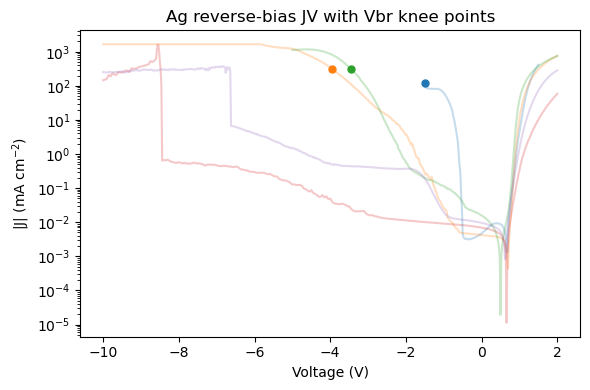

In [71]:
plt.figure(figsize=(6,4))

for (htl, src), g in curves.groupby(["HTL", "SourceFile"]):
    g = g.sort_values("voltage")
    V = g["voltage"].to_numpy()
    J = np.abs(g["current"].to_numpy())
    if np.nanmax(J) < 1:
        J = J * 1000

    plt.plot(V, J, alpha=0.25)

    vbr = vbr_all.loc[(vbr_all["HTL"]==htl) & (vbr_all["SourceFile"]==src), "Vbr"].values[0]
    if np.isfinite(vbr):
        i = np.argmin(np.abs(V - vbr))
        plt.scatter(V[i], J[i], s=25)

plt.yscale("log")
plt.xlabel("Voltage (V)")
plt.ylabel("|J| (mA cm$^{-2}$)")
plt.title("Ag reverse-bias JV with Vbr knee points")
plt.tight_layout()
plt.show()

In [73]:
# Create results folder if it doesn't exist
import os
os.makedirs("../results", exist_ok=True)

# Save raw extracted Vbr per curve
vbr_all.to_csv("../results/vbr_Ag_per_curve.csv", index=False)

# Save summary per HTL
vbr_summary.to_csv("../results/vbr_Ag_summary.csv")

print("Saved:")
print("  ../results/vbr_Ag_per_curve.csv")
print("  ../results/vbr_Ag_summary.csv")

Saved:
  ../results/vbr_Ag_per_curve.csv
  ../results/vbr_Ag_summary.csv


In [74]:
# Create figures folder if it doesn't exist
os.makedirs("../figures", exist_ok=True)

plt.savefig("../figures/Ag_reverse_bias_Vbr_knee.png", dpi=300, bbox_inches="tight")
print("Saved: ../figures/Ag_reverse_bias_Vbr_knee.png")

Saved: ../figures/Ag_reverse_bias_Vbr_knee.png


<Figure size 640x480 with 0 Axes>

In [75]:
vbr_all.to_csv("../results/vbr_all_devices.csv", index=False)
